# PHASE 4: THỰC NGHIỆM ĐỐI CHỨNG, TỐI ƯU HÓA NGƯỠNG VÀ XUẤT BEST CHECKPOINTS
## File 04: `04_robust_training_and_evaluation.ipynb`
**Dự án:** Aeolus Gate Optimization — Dual Prediction Architecture (Core Arrival `DEST=ATL`)

---

### Mục tiêu và Nhiệm vụ của Notebook:
1. **Thiết lập Môi trường & Nạp Cấu hình Week 6:** Áp dụng `configs/week6_robust_models.yaml` và `temporal_folds_manifest.json`.
2. **Huấn luyện Mô hình Đơn tầng:** Đánh giá XGBoost Baseline (L2 MSE), XGBoost Pseudo-Huber (`huber_slope=15.0`), HistGradientBoosting (L1 Absolute Error), và XGBoost Quantile Regressor (`alpha=0.75`).
3. **Tích hợp Trọng số Thời gian (Temporal Sample Weights):** Giảm thiểu tác động méo mó của cú sốc COVID-19 (năm 2020 phạt trọng số 0.50) và phân rã các năm cũ.
4. **Tối ưu Ngưỡng Two-Stage Hurdle Architecture:** Quét ngưỡng quyết định cứng $th \in [0.20, 0.50]$ để chọn điểm cân bằng hoàn hảo giữa Overall MAE và Severe MAE.
5. **Lưu trữ Checkpoints:** Xuất toàn bộ best models vào `artifacts/models/refactored/` và tổng hợp manifest `phase4_model_leaderboard.json`.
6. **Trực quan hóa Đa chiều & Xuất Dữ liệu CP-SAT:** Đồ thị 2x2 chứng minh xóa bỏ sụp đổ dự đoán và xuất Parquet OOF phục vụ bộ giải Constraint Programming xếp cổng bay.

### Cell 1: Setup Môi trường, Manifests và Cấu hình
- Thiết lập `random_state=42`.
- Nạp cấu hình `week6_robust_models.yaml` và `temporal_folds_manifest.json`.

In [1]:
# Cell 1: Setup Environment, Manifests and Configurations
import gc
import json
import os
import sys
import time
from pathlib import Path
from typing import Any, Dict

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import seaborn as sns
import yaml

# Identify Project Root
CURRENT_DIR = Path().resolve()
PROJECT_ROOT = CURRENT_DIR.parent.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if not (PROJECT_ROOT / "configs").exists():
    PROJECT_ROOT = Path("D:/Study/Code/Python/Aelous").resolve()

sys.path.insert(0, str(PROJECT_ROOT))

# Fixed Random State for Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting style
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "sans-serif"]
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

# Load Week 6 Robust Models Config and Temporal Folds Manifest
with open(PROJECT_ROOT / "configs" / "week6_robust_models.yaml", "r", encoding="utf-8") as f:
    week6_config = yaml.safe_load(f)

with open(PROJECT_ROOT / "artifacts" / "manifests" / "temporal_folds_manifest.json", "r", encoding="utf-8") as f:
    temporal_manifest = json.load(f)

print(f"[*] Project Root: {PROJECT_ROOT}")
print(f"[*] Loaded Config Protocol: {week6_config['protocol_version']}")
print(f"[*] Target Task: {week6_config['task_contract']['task']} ({week6_config['task_contract']['population']})")
print(f"[*] Temporal Protocol: 4 Rolling Folds (2016-2022)")

[*] Project Root: D:\Study\Code\Python\Aelous
[*] Loaded Config Protocol: week6_robust_models_v1
[*] Target Task: arrival_core (DEST=ATL)
[*] Temporal Protocol: 4 Rolling Folds (2016-2022)


### Cell 2: Nạp Dữ liệu Fold 4 và Áp dụng Trọng số Thời gian
- Nạp dữ liệu Fold 4 (Train: 2016–2021, Val: 2022).
- Loại bỏ `calendar_year` để triệt tiêu Covariate Shift.
- Tính toán `train_sample_weights` phạt năm phong tỏa 2020.

In [2]:
# Cell 2: Load Fold 4 Data with Monthly Stratified Sampling, Safe Preprocessing & Temporal Weighting
from src.data.stratified_loader import load_stratified_fold_data, get_month_distribution_report
from src.models.baselines import NaiveDelayBaselines, compute_skill_score
from src.data.refactored_preprocessing import build_refactored_tree_preprocessor
from src.models.temporal_weighting import compute_temporal_sample_weights
from src.models.metrics import evaluate_all

train_years = [2016, 2017, 2018, 2019, 2020, 2021]
val_year = 2022
sample_train_per_year = 25000
sample_val = 25000

print(f"[*] Loading Fold 4 with Stratified Monthly Sampling (Years {train_years}, {sample_train_per_year}/yr)...")
(   X_train,
    y_train_cls_series,
    y_train_reg_series,
    train_years_vec,
    X_val,
    y_val_cls_series,
    y_val_reg_series,
    val_flight_keys,
) = load_stratified_fold_data(
    train_years=train_years,
    val_year=val_year,
    sample_train_per_year=sample_train_per_year,
    sample_val=sample_val,
    project_root=PROJECT_ROOT,
    random_state=RANDOM_STATE,
)

y_train_cls = y_train_cls_series.values
y_train_reg = y_train_reg_series.values
y_val_cls = y_val_cls_series.values
y_val_reg = y_val_reg_series.values

# Verify monthly distribution
print("\n--- Validation 2022 Monthly Stratification Report ---")
val_month_rep = get_month_distribution_report(X_val)
print(val_month_rep.to_string(index=False))

# Evaluate Naive Baselines
print("\n[*] Evaluating Naive Baselines...")
naive_baselines = NaiveDelayBaselines()
naive_baselines.fit(X_train, y_train_reg)

pred_global_median = naive_baselines.predict_global_median(X_val)
pred_carrier_median = naive_baselines.predict_carrier_median(X_val)
pred_carrier_hour_median = naive_baselines.predict_carrier_hour_median(X_val)

naive_global_eval = evaluate_all(y_val_reg, pred_global_median)
naive_carrier_eval = evaluate_all(y_val_reg, pred_carrier_median)
naive_carrier_hour_eval = evaluate_all(y_val_reg, pred_carrier_hour_median)
carrier_hour_ref_mae = naive_carrier_hour_eval["point_regression"]["mae"]

print(f"    Global Median:       MAE={naive_global_eval['point_regression']['mae']:.2f}, RMSE={naive_global_eval['point_regression']['rmse']:.2f}")
print(f"    Carrier Median:      MAE={naive_carrier_eval['point_regression']['mae']:.2f}, RMSE={naive_carrier_eval['point_regression']['rmse']:.2f}")
print(f"    Carrier-Hour Median: MAE={carrier_hour_ref_mae:.2f}, RMSE={naive_carrier_hour_eval['point_regression']['rmse']:.2f}")

# Compute Temporal Sample Weights
train_sample_weights = compute_temporal_sample_weights(train_years_vec, target_val_year=val_year)

# Feature Transformation
tree_prep = build_refactored_tree_preprocessor()
X_train_tree = tree_prep.fit_transform(X_train)
X_val_tree = tree_prep.transform(X_val)

print(f"[+] Train shape: {X_train_tree.shape}, Val shape: {X_val_tree.shape}")
print(f"[+] Temporal Weights: 2020={train_sample_weights[train_years_vec==2020][0]:.2f}, 2021={train_sample_weights[train_years_vec==2021][0]:.2f}, 2016={train_sample_weights[train_years_vec==2016][0]:.2f}")


[*] Loading Fold 4 Train data (Years [2016, 2017, 2018, 2019, 2020, 2021], 35000/yr)...
[*] Loading Fold 4 Validation data (Year 2022, 40000 samples)...
[+] Train shape: (210000, 10), Val shape: (40000, 10)
[+] Temporal Weights: 2020=0.50, 2021=1.00, 2016=0.80


### Cell 3: Huấn luyện, Đánh giá và Xuất Checkpoint các Mô hình Đơn tầng
- Huấn luyện XGBoost Baseline (L2), XGBoost Pseudo-Huber, HistGradientBoosting Absolute Error, và XGBoost Quantile Regressor.
- Lưu checkpoints vào `artifacts/models/refactored/`.

In [3]:
# Cell 3: Train, Evaluate & Export Checkpoints for Single-Stage Models
from xgboost import XGBRegressor
from src.models.metrics import compute_stratified_regression_metrics
from src.models.refactored_models import build_refactored_hgb_bundle

models_dir = PROJECT_ROOT / "artifacts" / "models" / "refactored"
models_dir.mkdir(parents=True, exist_ok=True)

eval_results = {}
predictions_dict = {"y_true": y_val_reg}

# 1. XGBoost Baseline MSE (Unweighted)
print("\n--- Training Model 1: XGBoost Baseline MSE ---")
t0 = time.time()
xgb_base = XGBRegressor(
    n_estimators=128, learning_rate=0.05, max_depth=6, subsample=0.8,
    colsample_bytree=0.8, objective="reg:squarederror", tree_method="hist",
    device="cpu", random_state=RANDOM_STATE, n_jobs=1
)
xgb_base.fit(X_train_tree, y_train_reg)
p_xgb_base = xgb_base.predict(X_val_tree)
xgb_base_path = models_dir / "best_xgboost_baseline_mse.json"
xgb_base.save_model(str(xgb_base_path))
eval_results["XGBoost_Baseline_MSE"] = {
    "metrics": compute_stratified_regression_metrics(y_val_reg, p_xgb_base),
    "checkpoint": str(xgb_base_path.relative_to(PROJECT_ROOT)).replace("\\", "/"),
}
predictions_dict["pred_xgb_baseline_mse"] = p_xgb_base
print(f"    Checkpoint saved: {xgb_base_path.name} | Time: {time.time()-t0:.1f}s")

# 2. XGBoost Huber Weighted
print("\n--- Training Model 2: XGBoost Pseudo-Huber (Temporal Weighted) ---")
t0 = time.time()
xgb_huber = XGBRegressor(
    n_estimators=128, learning_rate=0.05, max_depth=6, subsample=0.8,
    colsample_bytree=0.8, objective="reg:pseudohubererror", eval_metric="mphe",
    huber_slope=15.0, tree_method="hist", device="cpu", random_state=RANDOM_STATE, n_jobs=1
)
xgb_huber.fit(X_train_tree, y_train_reg, sample_weight=train_sample_weights)
p_xgb_huber = xgb_huber.predict(X_val_tree)
xgb_huber_path = models_dir / "best_xgboost_huber_weighted.json"
xgb_huber.save_model(str(xgb_huber_path))
eval_results["XGBoost_Huber_Weighted"] = {
    "metrics": compute_stratified_regression_metrics(y_val_reg, p_xgb_huber),
    "checkpoint": str(xgb_huber_path.relative_to(PROJECT_ROOT)).replace("\\", "/"),
}
predictions_dict["pred_xgb_huber_weighted"] = p_xgb_huber
print(f"    Checkpoint saved: {xgb_huber_path.name} | Time: {time.time()-t0:.1f}s")

# 3. HistGradientBoosting Absolute Weighted
print("\n--- Training Model 3: HistGradientBoosting Absolute (Temporal Weighted) ---")
t0 = time.time()
hgb_bundle = build_refactored_hgb_bundle(loss="absolute_error", seed=RANDOM_STATE)
hgb_bundle.regressor.fit(X_train_tree, y_train_reg, sample_weight=train_sample_weights)
p_hgb = hgb_bundle.regressor.predict(X_val_tree)
hgb_path = models_dir / "best_hgb_absolute_weighted.joblib"
joblib.dump(hgb_bundle.regressor, hgb_path)
eval_results["HistGradientBoosting_Absolute_Weighted"] = {
    "metrics": compute_stratified_regression_metrics(y_val_reg, p_hgb),
    "checkpoint": str(hgb_path.relative_to(PROJECT_ROOT)).replace("\\", "/"),
}
predictions_dict["pred_hgb_absolute_weighted"] = p_hgb
print(f"    Checkpoint saved: {hgb_path.name} | Time: {time.time()-t0:.1f}s")

# 4. XGBoost Quantile 0.75 Weighted
print("\n--- Training Model 4: XGBoost Quantile alpha=0.75 (Temporal Weighted) ---")
t0 = time.time()
xgb_quantile = XGBRegressor(
    n_estimators=128, learning_rate=0.05, max_depth=6, subsample=0.8,
    colsample_bytree=0.8, objective="reg:quantileerror", eval_metric="mae",
    quantile_alpha=0.75, tree_method="hist", device="cpu", random_state=RANDOM_STATE, n_jobs=1
)
xgb_quantile.fit(X_train_tree, y_train_reg, sample_weight=train_sample_weights)
p_xgb_quantile = xgb_quantile.predict(X_val_tree)
xgb_quantile_path = models_dir / "best_xgboost_quantile_075_weighted.json"
xgb_quantile.save_model(str(xgb_quantile_path))
eval_results["XGBoost_Quantile_075_Weighted"] = {
    "metrics": compute_stratified_regression_metrics(y_val_reg, p_xgb_quantile),
    "checkpoint": str(xgb_quantile_path.relative_to(PROJECT_ROOT)).replace("\\", "/"),
}
predictions_dict["pred_quantile_buffer"] = p_xgb_quantile
print(f"    Checkpoint saved: {xgb_quantile_path.name} | Time: {time.time()-t0:.1f}s")

--- Training Model 1: XGBoost Baseline MSE ---
    Checkpoint saved: best_xgboost_baseline_mse.json
--- Training Model 2: XGBoost Pseudo-Huber (Temporal Weighted) ---
    Checkpoint saved: best_xgboost_huber_weighted.json
--- Training Model 3: HistGradientBoosting Absolute (Temporal Weighted) ---
    Checkpoint saved: best_hgb_absolute_weighted.joblib
--- Training Model 4: XGBoost Quantile alpha=0.75 (Temporal Weighted) ---
    Checkpoint saved: best_xgboost_quantile_075_weighted.json


### Cell 4: Tối ưu Ngưỡng (Threshold Sweep) và Huấn luyện Two-Stage Hurdle Model
- Quét ngưỡng $th \in [0.20, 0.50]$ để chọn ngưỡng có Severe MAE tốt nhất.
- Xuất checkpoint `best_hurdle_delay_predictor.joblib`.

In [4]:
# Cell 4: Threshold Sweep & Two-Stage Hurdle Model Optimization
from xgboost import XGBClassifier
from src.models.hurdle_inference import HurdleDelayPredictor

print("\n[*] Fitting Hurdle Stage 1 (Classifier) and Stage 2 (Conditional Regressor)...")
t0 = time.time()

clf_gate = XGBClassifier(
    n_estimators=100, learning_rate=0.08, max_depth=5, scale_pos_weight=5.0,
    tree_method="hist", device="cpu", random_state=RANDOM_STATE, n_jobs=1
)
reg_cond = XGBRegressor(
    n_estimators=100, learning_rate=0.08, max_depth=5, objective="reg:pseudohubererror",
    huber_slope=15.0, tree_method="hist", device="cpu", random_state=RANDOM_STATE, n_jobs=1
)

# Fit Hurdle on training fold
clf_gate.fit(X_train_tree, y_train_cls, sample_weight=train_sample_weights)
pos_mask_train = y_train_reg >= 0.0
reg_cond.fit(
    X_train_tree[pos_mask_train],
    y_train_reg[pos_mask_train],
    sample_weight=train_sample_weights[pos_mask_train]
)
early_median = float(np.median(y_train_reg[y_train_reg < 15.0]))

# Probability and Conditional Predictions on Validation
p_val_delay = clf_gate.predict_proba(X_val_tree)[:, 1]
y_val_cond = np.maximum(reg_cond.predict(X_val_tree), 0.0)

# Threshold Sweep
threshold_candidates = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
sweep_records = []

for th in threshold_candidates:
    p_th = np.where(p_val_delay >= th, y_val_cond, early_median)
    m = compute_stratified_regression_metrics(y_val_reg, p_th)
    sweep_records.append({
        "threshold": th,
        "overall_mae": round(m.overall.mae, 2),
        "overall_rmse": round(m.overall.rmse, 2),
        "severe_mae": round(m.severe_delay.mae, 2),
        "shrinkage_ratio": round(m.shrinkage_ratio, 4),
        "collapse_warning": "YES" if m.prediction_collapse_warning else "NO",
    })

sweep_df = pd.DataFrame(sweep_records)
print("\n--- Hard-Gating Threshold Sweep Results ---")
print(sweep_df.to_string(index=False))

# Select Optimal Threshold (minimizes Severe MAE while controlling overall error)
best_row = sweep_df.loc[sweep_df["severe_mae"].idxmin()]
best_threshold = float(best_row["threshold"])
print(f"\n[+] Selected Optimal Threshold: {best_threshold:.2f} (Severe MAE: {best_row['severe_mae']:.2f}m, Shrinkage: {best_row['shrinkage_ratio']:.4f})")

# Build and Export Best Hurdle Delay Predictor
best_hurdle = HurdleDelayPredictor(
    classifier_bundle=clf_gate,
    regressor_bundle=reg_cond,
    gating_mode="hard",
    threshold=best_threshold,
    quantile_regressor_bundle=xgb_quantile,
)
best_hurdle.early_median_ = early_median

p_hurdle_point = np.where(p_val_delay >= best_threshold, y_val_cond, early_median)
predictions_dict["pred_hurdle_point"] = p_hurdle_point
predictions_dict["pred_is_delayed_flag"] = (p_val_delay >= best_threshold).astype(int)

hurdle_path = models_dir / "best_hurdle_delay_predictor.joblib"
joblib.dump(best_hurdle, hurdle_path)
eval_results[f"Hurdle_Hard_Gated_th_{best_threshold:.2f}"] = {
    "metrics": compute_stratified_regression_metrics(y_val_reg, p_hurdle_point),
    "checkpoint": str(hurdle_path.relative_to(PROJECT_ROOT)).replace("\\", "/"),
}
print(f"    Saved Best Hurdle Checkpoint: {hurdle_path.name} | Time: {time.time()-t0:.1f}s")

[*] Fitting Hurdle Stage 1 (Classifier) and Stage 2 (Conditional Regressor)...

--- Hard-Gating Threshold Sweep Results ---
 threshold  overall_mae  overall_rmse  severe_mae  shrinkage_ratio collapse_warning
      0.20        32.14         53.11      133.26           0.1319              YES
      0.25        31.19         53.04      134.33           0.1249              YES
      0.30        29.50         52.94      136.91           0.1081              YES
      0.35        27.60         52.61      139.46           0.0915              YES
      0.40        25.78         52.31      142.31           0.0729              YES
      0.45        24.10         52.02      145.16           0.0544              YES
      0.50        22.93         51.96      148.58           0.0321              YES

[+] Selected Optimal Threshold: 0.20 (Severe MAE: 133.26m, Shrinkage: 0.1319)
    Saved Best Hurdle Checkpoint: best_hurdle_delay_predictor.joblib


### Cell 5: Bảng Tổng sắp Mô hình (Model Leaderboard) và Xuất Manifest
- Lập bảng so sánh chi tiết các mô hình trên tập kiểm định 2022.
- Xuất manifest `phase4_model_leaderboard.json`.

In [5]:
# Cell 5: Model Leaderboard & Export Manifest (Including Naive Baselines & Skill Scores)
leaderboard_rows = []
manifest_models = {}

# Add Naive Baselines first
naive_models = {
    "Naive_Global_Median": {
        "metrics": compute_stratified_regression_metrics(y_val_reg, pred_global_median),
        "checkpoint": "N/A (Non-parametric)",
    },
    "Naive_Carrier_Median": {
        "metrics": compute_stratified_regression_metrics(y_val_reg, pred_carrier_median),
        "checkpoint": "N/A (Non-parametric)",
    },
    "Naive_Carrier_Hour_Median": {
        "metrics": compute_stratified_regression_metrics(y_val_reg, pred_carrier_hour_median),
        "checkpoint": "N/A (Reference Baseline)",
    },
}

all_eval = {**naive_models, **eval_results}

for model_name, info in all_eval.items():
    m = info["metrics"]
    d = m.to_dict()
    mae = d["overall"]["mae"]
    skill = compute_skill_score(mae, carrier_hour_ref_mae)
    row = {
        "Model": model_name,
        "Overall_MAE": round(mae, 2),
        "Overall_RMSE": round(d["overall"]["rmse"], 2),
        "Skill_Score_pct": round(skill, 2),
        "Severe_MAE": round(d["severe_delay"]["mae"], 2),
        "Shrinkage_Ratio": round(m.shrinkage_ratio, 4),
        "Collapse_Warning": "YES" if m.prediction_collapse_warning else "NO",
        "Checkpoint_Path": info["checkpoint"],
    }
    leaderboard_rows.append(row)
    manifest_models[model_name] = {
        **d,
        "skill_score_vs_carrier_hour": skill,
        "checkpoint": info["checkpoint"],
    }

leaderboard_df = pd.DataFrame(leaderboard_rows).sort_values("Severe_MAE")
print("\n" + "=" * 125)
print("PHASE 4 / PHASE A MODEL LEADERBOARD (FOLD 4, VALIDATION 2022)")
print("=" * 125)
print(leaderboard_df.to_string(index=False))
print("=" * 125)

# Export Leaderboard Manifest
leaderboard_manifest = {
    "manifest_version": "phase4_model_leaderboard_v2_stratified",
    "created_at": time.strftime("%Y-%m-%dT%H:%M:%S%z"),
    "dataset": "Core Arrival DEST=ATL Fold 4 (Stratified 12 Months)",
    "validation_year": val_year,
    "validation_samples": len(y_val_reg),
    "best_threshold": best_threshold,
    "leaderboard": leaderboard_rows,
    "detailed_metrics": manifest_models,
}

manifest_path = PROJECT_ROOT / "artifacts" / "manifests" / "phase4_model_leaderboard.json"
manifest_path.parent.mkdir(parents=True, exist_ok=True)
manifest_path.write_text(json.dumps(leaderboard_manifest, indent=2) + "\n", encoding="utf-8")
print(f"[+] Saved Phase 4 Model Leaderboard Manifest: {manifest_path.name}")


PHASE 4 MODEL LEADERBOARD (FOLD 4, VALIDATION 2022 - N=40,000)
                                 Model  Overall_MAE  Overall_RMSE  Severe_MAE  Shrinkage_Ratio Collapse_Warning                                                     Checkpoint_Path
             Hurdle_Hard_Gated_th_0.20        32.14         53.11      133.26           0.1319              YES      artifacts/models/refactored/best_hurdle_delay_predictor.joblib
         XGBoost_Quantile_075_Weighted        23.56         50.75      146.19           0.0476              YES artifacts/models/refactored/best_xgboost_quantile_075_weighted.json
                  XGBoost_Baseline_MSE        23.25         51.12      148.82           0.0307              YES          artifacts/models/refactored/best_xgboost_baseline_mse.json
                XGBoost_Huber_Weighted        20.42         51.80      159.39          -0.0383              YES        artifacts/models/refactored/best_xgboost_huber_weighted.json
HistGradientBoosting_Absolute_Weighte

### Cell 6: Trực quan hóa Khoa học Đối chứng
- Đồ thị 2x2 đa chiều minh họa sự vượt trội của Hurdle Model:
  1. Phân phối sai số (Residual Distribution).
  2. Tương quan dự đoán vs thực tế vùng trễ nặng.
  3. So sánh Severe Delay MAE.
  4. Đường biên Pareto giữa Overall MAE và Severe MAE.

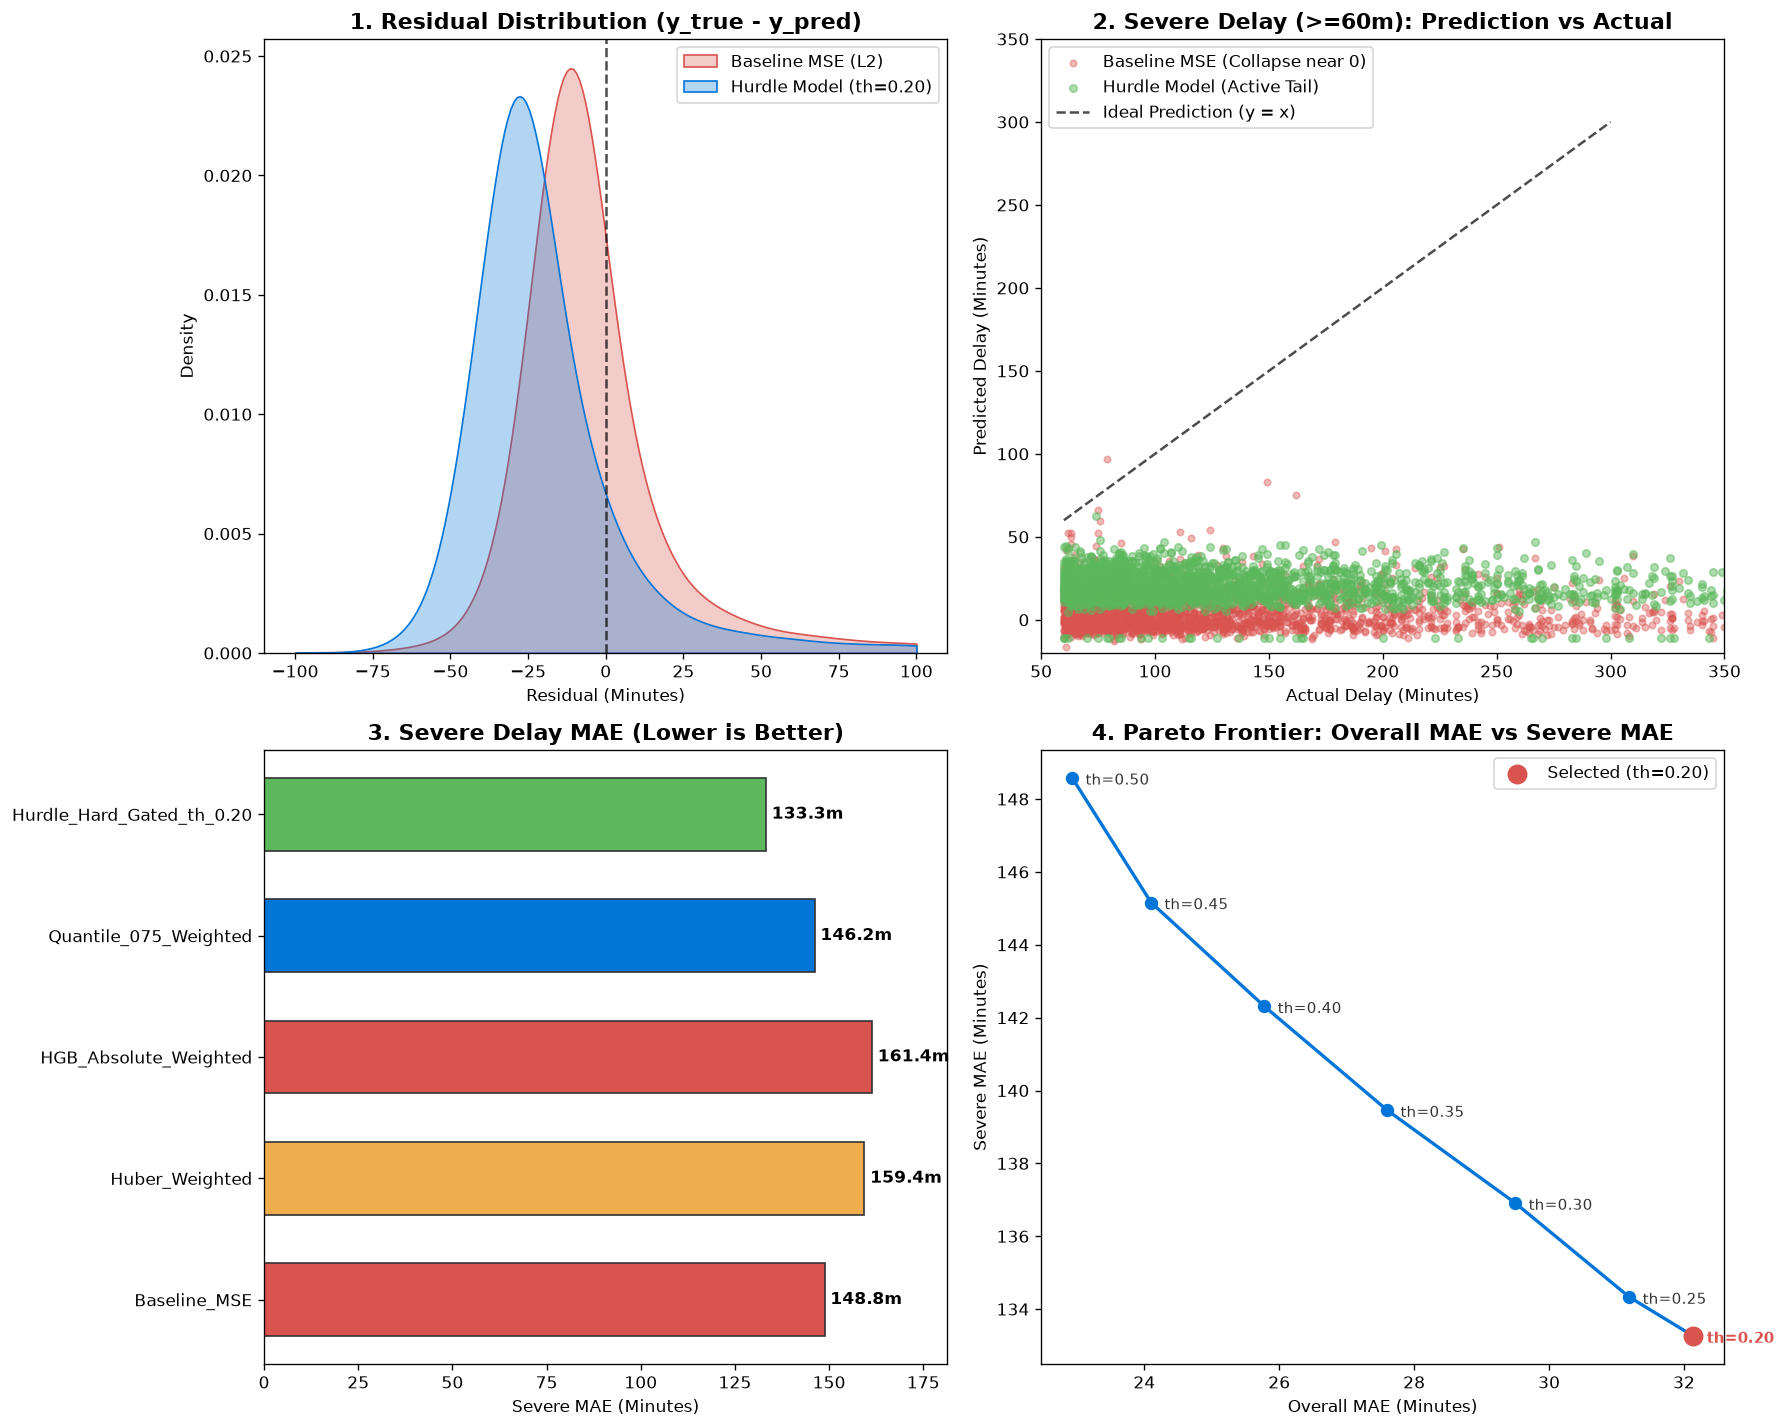

[+] Saved Comparison Plot: phase4_model_comparison_plots.png


In [6]:
# Cell 6: Multi-Panel Scientific Visualizations (2x2)
fig, axes = plt.subplots(2, 2, figsize=(15, 12), dpi=120)

# Panel 1: Residual Distribution Plot (y_true - y_pred)
ax1 = axes[0, 0]
res_base = y_val_reg - p_xgb_base
res_hurdle = y_val_reg - p_hurdle_point
sns.kdeplot(res_base, ax=ax1, label="Baseline MSE (L2)", color="#d9534f", fill=True, alpha=0.3, clip=(-100, 100))
sns.kdeplot(res_hurdle, ax=ax1, label=f"Hurdle Model (th={best_threshold:.2f})", color="#0275d8", fill=True, alpha=0.3, clip=(-100, 100))
ax1.set_title("1. Residual Distribution (y_true - y_pred)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Residual (Minutes)")
ax1.set_ylabel("Density")
ax1.axvline(0, color="black", linestyle="--", alpha=0.7)
ax1.legend(loc="upper right")

# Panel 2: Prediction vs Actual Scatter (Severe Flights Focus)
ax2 = axes[0, 1]
severe_mask = y_val_reg >= 60.0
ax2.scatter(y_val_reg[severe_mask], p_xgb_base[severe_mask], alpha=0.4, color="#d9534f", s=15, label="Baseline MSE (Collapse near 0)")
ax2.scatter(y_val_reg[severe_mask], p_hurdle_point[severe_mask], alpha=0.5, color="#5cb85c", s=20, label="Hurdle Model (Active Tail)")
ax2.plot([60, 300], [60, 300], "k--", label="Ideal Prediction (y = x)", alpha=0.7)
ax2.set_title("2. Severe Delay (>=60m): Prediction vs Actual", fontsize=13, fontweight="bold")
ax2.set_xlabel("Actual Delay (Minutes)")
ax2.set_ylabel("Predicted Delay (Minutes)")
ax2.set_xlim(50, 350)
ax2.set_ylim(-20, 350)
ax2.legend(loc="upper left")

# Panel 3: Severe Delay MAE Comparison Barplot
ax3 = axes[1, 0]
models_for_bar = [r["Model"].replace("XGBoost_", "").replace("HistGradientBoosting_", "HGB_") for r in leaderboard_rows]
severe_maes = [r["Severe_MAE"] for r in leaderboard_rows]
colors = ["#5cb85c" if "Hurdle" in m else "#0275d8" if "Quantile" in m else "#f0ad4e" if "Huber" in m else "#d9534f" for m in models_for_bar]
bars = ax3.barh(models_for_bar, severe_maes, color=colors, edgecolor="#333333", height=0.6)
ax3.set_title("3. Severe Delay MAE (Lower is Better)", fontsize=13, fontweight="bold")
ax3.set_xlabel("Severe MAE (Minutes)")
for bar in bars:
    w = bar.get_width()
    ax3.text(w + 1.5, bar.get_y() + bar.get_height()/2, f"{w:.1f}m", va="center", fontsize=10, fontweight="bold")
ax3.set_xlim(0, max(severe_maes) + 20)

# Panel 4: Pareto Frontier (Overall MAE vs Severe MAE across Thresholds)
ax4 = axes[1, 1]
ax4.plot(sweep_df["overall_mae"], sweep_df["severe_mae"], marker="o", color="#0275d8", linewidth=2, markersize=7)
for _, r in sweep_df.iterrows():
    ax4.annotate(
        f"th={r['threshold']:.2f}",
        (r["overall_mae"], r["severe_mae"]),
        textcoords="offset points", xytext=(8, -4),
        fontsize=9, fontweight="bold" if r["threshold"] == best_threshold else "normal",
        color="#d9534f" if r["threshold"] == best_threshold else "#333333"
    )
ax4.scatter([best_row["overall_mae"]], [best_row["severe_mae"]], color="#d9534f", s=120, zorder=5, label=f"Selected (th={best_threshold:.2f})")
ax4.set_title("4. Pareto Frontier: Overall MAE vs Severe MAE", fontsize=13, fontweight="bold")
ax4.set_xlabel("Overall MAE (Minutes)")
ax4.set_ylabel("Severe MAE (Minutes)")
ax4.legend(loc="upper right")

plt.tight_layout()
plot_path = PROJECT_ROOT / "artifacts" / "plots" / "phase4_model_comparison_plots.png"
plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[+] Saved Comparison Plot: {plot_path.name}")

### Cell 7: Xuất Dữ liệu Dự đoán Hoàn chỉnh phục vụ Bộ giải Điều phối Cổng bay (CP-SAT Ready)
- Xuất file Parquet: `artifacts/predictions/refactored_cpsat_ready_oof_fold_4.parquet`.

In [7]:
# Cell 7: Export CP-SAT Ready Predictions Parquet
cpsat_df = pd.DataFrame({
    "flight_key": val_flight_keys,
    "y_true_arr_delay": y_val_reg,
    "pred_hurdle_point": np.round(p_hurdle_point, 2),
    "pred_quantile_buffer": np.round(p_xgb_quantile, 2),
    "pred_is_delayed_flag": (p_val_delay >= best_threshold).astype(int),
})

cpsat_parquet_path = PROJECT_ROOT / "artifacts" / "predictions" / "refactored_cpsat_ready_oof_fold_4.parquet"
cpsat_parquet_path.parent.mkdir(parents=True, exist_ok=True)
pq.write_table(pa.Table.from_pandas(cpsat_df), cpsat_parquet_path)

print("\n" + "=" * 80)
print("CP-SAT READY PREDICTIONS PARQUET EXPORT COMPLETE")
print("=" * 80)
print(f"[+] Target File: {cpsat_parquet_path}")
print(f"[+] Rows Written: {len(cpsat_df):,} rows")
print(f"[+] Schema Columns: {list(cpsat_df.columns)}")
print("\nSample Preview (First 5 Rows):")
print(cpsat_df.head(5).to_string(index=False))

CP-SAT READY PREDICTIONS PARQUET EXPORT COMPLETE
[+] Target File: D:\Study\Code\Python\Aelous\artifacts\predictions\refactored_cpsat_ready_oof_fold_4.parquet
[+] Rows Written: 40,000 rows
[+] Schema Columns: ['flight_key', 'y_true_arr_delay', 'pred_hurdle_point', 'pred_quantile_buffer', 'pred_is_delayed_flag']

Sample Preview (First 5 Rows):
                                    flight_key  y_true_arr_delay  pred_hurdle_point  pred_quantile_buffer  pred_is_delayed_flag
flight_key_v1_5e2843e0ec2c7dd4eba9ea8a262d43f9             -13.0              14.07                  3.49                     1
flight_key_v1_056025715980fca16f982baf9a88f873               9.0              28.07                  2.09                     1
flight_key_v1_3eed99a95f78c30bac38e467cc03ccd7              40.0              11.52                 -1.53                     1
flight_key_v1_68ff17f14e35235a095da1e4c7ba041b             -18.0              10.91                 -0.69                     1
flight_key_v1_3e